# 📊 Analyse A/B Testing Marketing - Optimisation Landing Page


---

## 🏢 Situation en Entreprise : A/B Testing pour Optimiser une Landing Page

**Contexte :**
La société fictive **ClickBoost**, spécialisée dans les solutions SaaS pour la gestion de campagnes publicitaires, souhaite améliorer le taux de conversion de sa landing page principale (*c'est la page sur laquelle les utilisateurs arrivent après avoir cliqué sur une annonce ou un lien*). L’équipe marketing a conçu une nouvelle version de la page d’accueil avec un design plus épuré et un appel à l’action plus visible.

**Objectif :**  
Déterminer si la nouvelle version de la landing page ("new_page") génère un meilleur taux de conversion que l’ancienne ("old_page").

**Méthodologie :**  
Un test A/B est lancé sur une période de 3 semaines. Les visiteurs sont aléatoirement répartis en deux groupes :
- **Groupe contrôle** : voit l’ancienne page
- **Groupe traitement** : voit la nouvelle page

Les données collectées incluent l’identifiant utilisateur, le moment de la visite, la version de la page affichée, et si l’utilisateur a converti (inscription, achat, etc.).

---

## 📊 Description des Variables du Dataset

| Variable       | Description                                                                 |
|----------------|------------------------------------------------------------------------------|
| `user_id`      | Identifiant unique de l’utilisateur                                          |
| `timestamp`    | Date et heure de la visite sur la landing page                              |
| `group`        | Groupe d’expérimentation : `control` (ancienne page) ou `treatment` (nouvelle page) |
| `landing_page` | Version de la page affichée : `old_page` ou `new_page`                      |
| `converted`    | Variable cible : `1` si l’utilisateur a converti, `0` sinon                 |

---

## 🔍 Extrait du Dataset

Voici un aperçu de quelques lignes du dataset :

```plaintext
user_id,timestamp,group,landing_page,converted
851104,2017-01-21 22:11:48.556739,control,old_page,0
804228,2017-01-12 08:01:45.159739,control,old_page,0
661590,2017-01-11 16:55:06.154213,treatment,new_page,0
864975,2017-01-21 01:52:26.210827,control,old_page,1
679687,2017-01-19 03:26:46.940749,treatment,new_page,1
817355,2017-01-04 17:58:08.979471,treatment,new_page,1
644214,2017-01-22 02:05:21.719434,control,old_page,1
888545,2017-01-08 06:37:26.332945,treatment,new_page,1
```

---


## 🎯 Objectif du Projet

Ce notebook présente une **analyse complète d'un test A/B** dans le contexte marketing pour déterminer quelle version d'une landing page convertit le mieux les utilisateurs.

### 📋 Problématique Business
- **Question centrale** : Quelle version de landing page (ancienne vs nouvelle) génère le meilleur taux de conversion ?
- **Impact** : Optimisation des campagnes marketing et amélioration du ROI (Return On Investment, ie rentabilité/retour sur investissement)
- **Métrique clé** : Taux de conversion (pourcentage d'utilisateurs qui effectuent l'action souhaitée)

### 🔬 Approche Méthodologique
1. **Exploration des données** - Compréhension du dataset et validation de la qualité
2. **Nettoyage et préparation** - Élimination des biais et incohérences
3. **Analyse descriptive** - Calcul des métriques de performance par groupe
4. **Tests statistiques** - Validation de la significativité des différences observées
5. **Visualisation** - Présentation claire des résultats
6. **Recommandations business** - Traduction des résultats en actions concrètes

---

## 📚 Import des Librairies et Configuration

Nous importons toutes les librairies nécessaires pour l'analyse statistique, la manipulation de données et la visualisation.

In [1]:
# Import des librairies principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import de nos fonctions personnalisées
from ab_testing_marketing_functions import *

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✅ Toutes les librairies ont été importées avec succès !")
print("📊 Configuration des graphiques terminée")

✅ Toutes les librairies ont été importées avec succès !
📊 Configuration des graphiques terminée


## 📂 Phase 1 : Chargement et Exploration des Données

### 🔍 Objectifs de cette phase :
- Charger le dataset A/B Testing
- Comprendre la structure des données
- Identifier les variables disponibles
- Détecter les problèmes potentiels de qualité des données

### 📊 Variables attendues :
- **user_id** : Identifiant unique de l'utilisateur
- **timestamp** : Date et heure de la visite
- **group** : Groupe d'assignation (control/treatment)
- **landing_page** : Version de la page (old_page/new_page)
- **converted** : Indicateur de conversion (0/1)

In [2]:
# Chargement et exploration initiale du dataset
print("🔄 Chargement du dataset A/B Testing...")
df_raw, exploration_stats = load_and_explore_data('ab_data.csv')

print(f"✅ Dataset chargé avec succès !")
print(f"📏 Dimensions : {exploration_stats['shape'][0]} lignes × {exploration_stats['shape'][1]} colonnes")
print(f"👥 Utilisateurs uniques : {exploration_stats['unique_users']:,}")
print(f"📅 Période : du {exploration_stats['date_range'][0].strftime('%Y-%m-%d')} au {exploration_stats['date_range'][1].strftime('%Y-%m-%d')}")

🔄 Chargement du dataset A/B Testing...
✅ Dataset chargé avec succès !
📏 Dimensions : 294478 lignes × 5 colonnes
👥 Utilisateurs uniques : 290,584
📅 Période : du 2017-01-02 au 2017-01-24


In [3]:
# Affichage des premières lignes pour comprendre la structure
print("🔍 Aperçu des données :")
display(df_raw.head(10))

# Informations sur le dataset
print("\n📊 Informations sur le dataset :")
display(df_raw.info())

🔍 Aperçu des données :


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
5,936923,2017-01-10 15:20:49.083499,control,old_page,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1



📊 Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.2+ MB


None

In [4]:
# Affichage aléatoire de 10 lignes
print("\n📊 Aperçu aléatoire des données :")
df_raw.sample(10)


📊 Aperçu aléatoire des données :


,user_id,timestamp,group,landing_page,converted
79862,675125,2017-01-05 21:46:12.517671,treatment,new_page,0
247601,760148,2017-01-03 20:16:38.136952,treatment,new_page,0
239142,782375,2017-01-04 14:22:57.029557,treatment,new_page,0
71355,680967,2017-01-13 06:55:30.559073,treatment,new_page,0
133642,939030,2017-01-20 05:26:05.805721,control,old_page,0
218491,768119,2017-01-11 07:57:04.164874,treatment,new_page,0
233884,923721,2017-01-24 04:48:17.367376,control,old_page,0
294049,923910,2017-01-04 12:07:50.793753,treatment,new_page,0
39460,902716,2017-01-05 05:49:01.541646,treatment,new_page,0
264705,872934,2017-01-05 09:38:40.950167,control,old_page,0


In [5]:
# Analyse des distributions
print("\n📈 DISTRIBUTION DES VARIABLES :")
print("\n🔵 Distribution des groupes :")
for group, count in exploration_stats['groups'].items():
    percentage = (count / exploration_stats['shape'][0]) * 100
    print(f"  • {group.capitalize()}: {count:,} ({percentage:.1f}%)")

print("\n🌐 Distribution des landing pages :")
for page, count in exploration_stats['landing_pages'].items():
    percentage = (count / exploration_stats['shape'][0]) * 100
    print(f"  • {page.replace('_', ' ').title()}: {count:,} ({percentage:.1f}%)")

print("\n💰 Distribution des conversions :")
for status, count in exploration_stats['conversion_summary'].items():
    label = "Convertis" if status == 1 else "Non convertis"
    percentage = (count / exploration_stats['shape'][0]) * 100
    print(f"  • {label}: {count:,} ({percentage:.1f}%)")


📈 DISTRIBUTION DES VARIABLES :

🔵 Distribution des groupes :
  • Treatment: 147,276 (50.0%)
  • Control: 147,202 (50.0%)

🌐 Distribution des landing pages :
  • Old Page: 147,239 (50.0%)
  • New Page: 147,239 (50.0%)

💰 Distribution des conversions :
  • Non convertis: 259,241 (88.0%)
  • Convertis: 35,237 (12.0%)


## 🔧 PHASE 2 : VALIDATION DE LA QUALITÉ DE L'EXPÉRIMENTATION

⚠️ POURQUOI CETTE ÉTAPE EST CRUCIALE ?

Un test A/B n'est valide que si l'expérimentation a été correctement menée.

🔍 VÉRIFICATIONS EFFECTUÉES :
1. Cohérence des assignations : Control → old_page, Treatment → new_page
2. Équilibrage des groupes : Tailles similaires pour éviter les biais
3. Absence de doublons : Chaque utilisateur une seule fois
4. Randomisation correcte : Assignation aléatoire aux groupes

🎯 CRITÈRES DE QUALITÉ :
- Incohérences < 5% du dataset
- Ratio des groupes entre 0.9 et 1.1
- Aucun doublon d'utilisateur

In [6]:
# Validation de l'expérimentation
print("🔍 Validation de la qualité de l'expérimentation A/B...")
validation_results = validate_experiment_design(df_raw)

print("\n📊 MATRICE DE COHÉRENCE Groupe × Landing Page :")
coherence_matrix = validation_results['coherence_matrix']
print(coherence_matrix)

# Analyse des incohérences
inconsistencies = validation_results['inconsistencies']
total_inconsistencies = inconsistencies['total_inconsistencies']
inconsistency_rate = (total_inconsistencies / exploration_stats['shape'][0]) * 100

print(f"\n⚠️ ANALYSE DES INCOHÉRENCES :")
print(f"  • Groupe Control avec New Page: {inconsistencies['control_with_new_page']:,}")
print(f"  • Groupe Treatment avec Old Page: {inconsistencies['treatment_with_old_page']:,}")
print(f"  • Total des incohérences: {total_inconsistencies:,} ({inconsistency_rate:.2f}%)")

if inconsistency_rate > 5:
    print("  🚨 ATTENTION: Taux d'incohérence élevé (>5%) - Qualité compromise")
else:
    print("  ✅ Taux d'incohérence acceptable (<5%)")

# Analyse de l'équilibrage
balance = validation_results['group_balance']
balance_ratio = balance['balance_ratio']

print(f"\n⚖️ ÉQUILIBRAGE DES GROUPES :")
print(f"  • Groupe Control: {balance['control_size']:,} utilisateurs")
print(f"  • Groupe Treatment: {balance['treatment_size']:,} utilisateurs")
print(f"  • Ratio Treatment/Control: {balance_ratio:.3f}")

if 0.9 <= balance_ratio <= 1.1:
    print("  ✅ Équilibrage acceptable (ratio entre 0.9 et 1.1)")
else:
    print("  ⚠️ Déséquilibre détecté - Peut affecter la validité")

# Analyse des doublons
duplicates = validation_results['duplicates']
duplicate_rate = (duplicates['duplicate_users'] / duplicates['total_records']) * 100

print(f"\n👥 ANALYSE DES DOUBLONS :")
print(f"  • Utilisateurs dupliqués: {duplicates['duplicate_users']:,}")
print(f"  • Utilisateurs uniques: {duplicates['unique_users']:,}")
print(f"  • Taux de duplication: {duplicate_rate:.2f}%")

if duplicates['duplicate_users'] == 0:
    print("  ✅ Aucun doublon détecté")
else:
    print("  ⚠️ Doublons détectés - Nettoyage nécessaire")

🔍 Validation de la qualité de l'expérimentation A/B...

📊 MATRICE DE COHÉRENCE Groupe × Landing Page :
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

⚠️ ANALYSE DES INCOHÉRENCES :
  • Groupe Control avec New Page: 1,928
  • Groupe Treatment avec Old Page: 1,965
  • Total des incohérences: 3,893 (1.32%)
  ✅ Taux d'incohérence acceptable (<5%)

⚖️ ÉQUILIBRAGE DES GROUPES :
  • Groupe Control: 147,202 utilisateurs
  • Groupe Treatment: 147,276 utilisateurs
  • Ratio Treatment/Control: 1.001
  ✅ Équilibrage acceptable (ratio entre 0.9 et 1.1)

👥 ANALYSE DES DOUBLONS :
  • Utilisateurs dupliqués: 3,894
  • Utilisateurs uniques: 290,584
  • Taux de duplication: 1.32%
  ⚠️ Doublons détectés - Nettoyage nécessaire


## 🧹 PHASE 3 : NETTOYAGE ET PRÉPARATION DES DONNÉES

🎯 OBJECTIFS DU NETTOYAGE :
Créer un dataset "propre" pour garantir la validité de l'analyse statistique :

1. Éliminer les incohérences : Supprimer les assignations incorrectes
2. Dédupliquer : Garder une seule occurrence par utilisateur
3. Valider la cohérence temporelle : Période cohérente

⚡ IMPACT ATTENDU :
- Réduction du bruit dans les données
- Amélioration de la fiabilité des tests statistiques
- Élimination des biais potentiels

In [7]:
# Nettoyage des données
print("🧹 Nettoyage du dataset...")
df_clean, cleaning_report = clean_data(df_raw)

print(f"\n📊 RAPPORT DE NETTOYAGE :")
print(f"  • Enregistrements initiaux: {cleaning_report['initial_records']:,}")
print(f"  • Enregistrements finaux: {cleaning_report['final_records']:,}")
print(f"  • Enregistrements supprimés: {cleaning_report['removed_records']:,}")
print(f"  • Pourcentage supprimé: {cleaning_report['removal_percentage']:.2f}%")

if cleaning_report['removal_percentage'] < 10:
    print("  ✅ Perte de données acceptable (<10%)")
else:
    print("  ⚠️ Perte de données importante (>10%)")

print(f"\n🎯 Dataset final prêt avec {len(df_clean):,} enregistrements")

# Vérification post-nettoyage
print("\n✅ VÉRIFICATION POST-NETTOYAGE :")
coherence_check = pd.crosstab(df_clean['group'], df_clean['landing_page'])
print("\n📊 Matrice de cohérence après nettoyage :")
print(coherence_check)

duplicates_after = df_clean['user_id'].duplicated().sum()
print(f"\n👥 Doublons restants: {duplicates_after}")

final_groups = df_clean['group'].value_counts()
final_ratio = final_groups['treatment'] / final_groups['control']
print(f"\n⚖️ Distribution finale :")
print(f"  • Control: {final_groups['control']:,}")
print(f"  • Treatment: {final_groups['treatment']:,}")
print(f"  • Ratio final: {final_ratio:.3f}")

🧹 Nettoyage du dataset...

📊 RAPPORT DE NETTOYAGE :
  • Enregistrements initiaux: 294,478
  • Enregistrements finaux: 290,584
  • Enregistrements supprimés: 3,894
  • Pourcentage supprimé: 1.32%
  ✅ Perte de données acceptable (<10%)

🎯 Dataset final prêt avec 290,584 enregistrements

✅ VÉRIFICATION POST-NETTOYAGE :

📊 Matrice de cohérence après nettoyage :
landing_page  new_page  old_page
group                           
control              0    145274
treatment       145310         0

👥 Doublons restants: 0

⚖️ Distribution finale :
  • Control: 145,274
  • Treatment: 145,310
  • Ratio final: 1.000


## 📊 PHASE 4 : ANALYSE DES TAUX DE CONVERSION

🎯 MÉTRIQUES CLÉS À ANALYSER :

1. Taux de conversion global : Performance générale
2. Taux de conversion par groupe :
   - Groupe Control : Performance ancienne landing page
   - Groupe Treatment : Performance nouvelle landing page
3. Lift (amélioration) :
   - Lift absolu : Différence brute entre les taux
   - Lift relatif : Pourcentage d'amélioration

📈 FORMULES UTILISÉES :
- Taux de conversion = Conversions / Total utilisateurs
- Lift absolu = Taux_treatment - Taux_control
- Lift relatif = (Lift absolu / Taux_control) × 100

In [8]:
# Calcul des métriques de conversion
print("📊 Calcul des taux de conversion...")
conversion_metrics = calculate_conversion_rates(df_clean)

# Métriques globales
overall = conversion_metrics['overall_metrics']
print(f"\n🌍 MÉTRIQUES GLOBALES :")
print(f"  • Total utilisateurs: {overall['total_users']:,}")
print(f"  • Total conversions: {overall['total_conversions']:,}")
print(f"  • Taux de conversion global: {overall['overall_conversion_rate']:.4f} ({overall['overall_conversion_rate']*100:.2f}%)")

# Analyse par groupe
by_group = conversion_metrics['by_group']
comparison = conversion_metrics['comparison']

print("\n🔍 ANALYSE DÉTAILLÉE PAR GROUPE :")
print("\n📊 Groupe CONTROL (Ancienne Landing Page) :")
control_stats = by_group['control']
print(f"  • Utilisateurs: {control_stats['total_users']:,}")
print(f"  • Conversions: {control_stats['conversions']:,}")
print(f"  • Taux: {control_stats['conversion_rate']:.4f} ({control_stats['conversion_rate']*100:.2f}%)")

print("\n🆕 Groupe TREATMENT (Nouvelle Landing Page) :")
treatment_stats = by_group['treatment']
print(f"  • Utilisateurs: {treatment_stats['total_users']:,}")
print(f"  • Conversions: {treatment_stats['conversions']:,}")
print(f"  • Taux: {treatment_stats['conversion_rate']:.4f} ({treatment_stats['conversion_rate']*100:.2f}%)")

# Performance comparative
print("\n🚀 ANALYSE DE PERFORMANCE :")
print(f"  • Lift absolu: {comparison['absolute_lift']:+.4f}")
print(f"  • Lift relatif: {comparison['relative_lift_percent']:+.2f}%")

if comparison['relative_lift_percent'] > 0:
    print(f"  ✅ La nouvelle page performe MIEUX (+{comparison['relative_lift_percent']:.2f}%)")
elif comparison['relative_lift_percent'] < 0:
    print(f"  ❌ La nouvelle page performe MOINS BIEN ({comparison['relative_lift_percent']:.2f}%)")
else:
    print(f"  ➖ Performance identique")

# Impact business estimé
monthly_visitors = 10000
current_monthly_conversions = monthly_visitors * comparison['control_rate']
potential_monthly_conversions = monthly_visitors * comparison['treatment_rate']
additional_conversions = potential_monthly_conversions - current_monthly_conversions

print(f"\n💰 IMPACT BUSINESS ESTIMÉ (sur {monthly_visitors:,} visiteurs/mois) :")
print(f"  • Conversions actuelles: {current_monthly_conversions:.0f}/mois")
print(f"  • Conversions potentielles: {potential_monthly_conversions:.0f}/mois")
print(f"  • Gain potentiel: {additional_conversions:.0f} conversions/mois")

📊 Calcul des taux de conversion...

🌍 MÉTRIQUES GLOBALES :
  • Total utilisateurs: 290,584
  • Total conversions: 34,753
  • Taux de conversion global: 0.1196 (11.96%)

🔍 ANALYSE DÉTAILLÉE PAR GROUPE :

📊 Groupe CONTROL (Ancienne Landing Page) :
  • Utilisateurs: 145,274
  • Conversions: 17,489
  • Taux: 0.1204 (12.04%)

🆕 Groupe TREATMENT (Nouvelle Landing Page) :
  • Utilisateurs: 145,310
  • Conversions: 17,264
  • Taux: 0.1188 (11.88%)

🚀 ANALYSE DE PERFORMANCE :
  • Lift absolu: -0.0016
  • Lift relatif: -1.33%
  ❌ La nouvelle page performe MOINS BIEN (-1.33%)

💰 IMPACT BUSINESS ESTIMÉ (sur 10,000 visiteurs/mois) :
  • Conversions actuelles: 1204/mois
  • Conversions potentielles: 1188/mois
  • Gain potentiel: -16 conversions/mois


## PHASE 5 : ANALYSE DESCRIPTIVE DÉTAILLÉE

🎯 OBJECTIF :
Comprendre plus finement les performances par groupe avec des intervalles de confiance
et des coupes temporelles (quotidien et horaire).

🔍 Calcul des métriques descriptives...

📋 RÉSUMÉ PAR GROUPE (IC 95%) :
  • Control   | n=145,274 | conv=17,489 | taux=0.1204 (12.04%) | IC95%=[0.1187, 0.1221]
  • Treatment | n=145,310 | conv=17,264 | taux=0.1188 (11.88%) | IC95%=[0.1171, 0.1205]

📈 ÉVOLUTION QUOTIDIENNE (taux de conversion) :


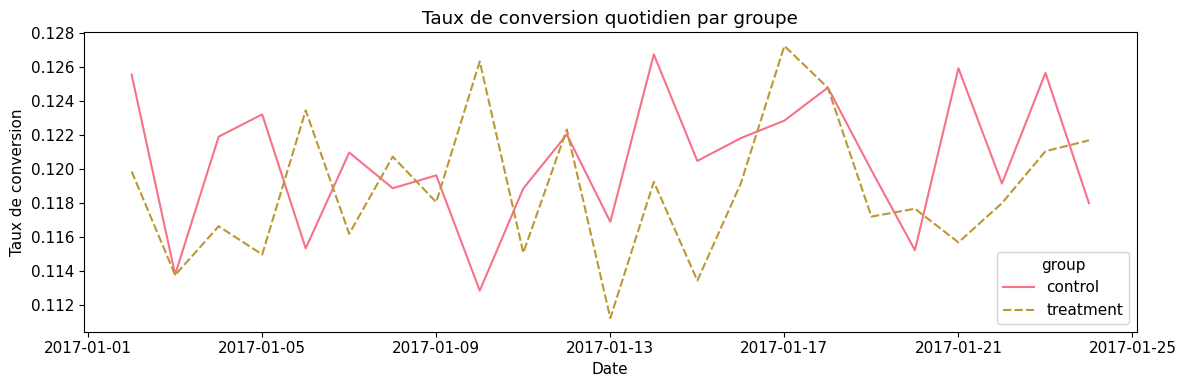


⏱️ PROFIL HORAIRE (taux de conversion) :


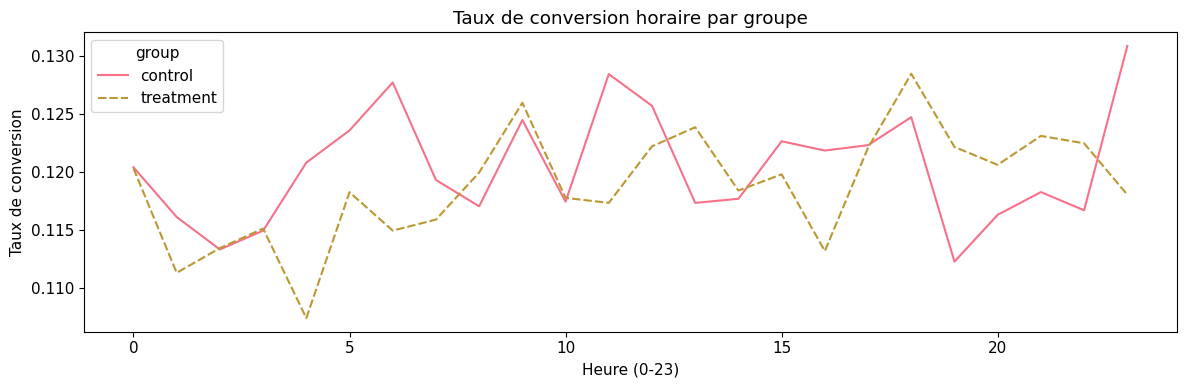

In [9]:
print("🔍 Calcul des métriques descriptives...")
desc = descriptive_group_metrics(df_clean)

print("\n📋 RÉSUMÉ PAR GROUPE (IC 95%) :")
for _, row in desc['summary_by_group'].iterrows():
    print(
        f"  • {row['group'].capitalize():9s} | n={int(row['n']):,} | conv={int(row['conversions']):,} | "
        f"taux={row['rate']:.4f} ({row['rate']*100:.2f}%) | IC95%=[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    )

# Évolution quotidienne par groupe
print("\n📈 ÉVOLUTION QUOTIDIENNE (taux de conversion) :")
try:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=desc['by_day'])
    plt.title("Taux de conversion quotidien par groupe")
    plt.ylabel("Taux de conversion")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  ⚠️ Impossible d'afficher le graphique quotidien: {e}")

# Évolution horaire par groupe
print("\n⏱️ PROFIL HORAIRE (taux de conversion) :")
try:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=desc['by_hour'])
    plt.title("Taux de conversion horaire par groupe")
    plt.ylabel("Taux de conversion")
    plt.xlabel("Heure (0-23)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"  ⚠️ Impossible d'afficher le graphique horaire: {e}")


## 📊 PHASE 6 : ANALYSE MULTIVARIÉE

🎯 OBJECTIF :
Identifier les facteurs influençant les conversions en utilisant la régression logistique.

In [10]:
print("🔍 Exécution de la régression logistique...")
logreg_results = run_logistic_regression(df_clean)

print("\n📊 RÉSUMÉ DE LA RÉGRESSION LOGISTIQUE :")
try:
    or_df = logreg_results['odds_ratios']
    pvals = logreg_results['pvalues']
    if isinstance(or_df, pd.DataFrame) and 'group_bin' in or_df.index:
        or_t = or_df.loc['group_bin']
        p_t = pvals.get('group_bin', np.nan)
        print(
            f"  • OR (treatment vs control): {or_t['odds_ratio']:.3f} "
            f"[{or_t['or_ci_low']:.3f}, {or_t['or_ci_high']:.3f}] | p-value={p_t:.4g}"
        )
    else:
        print("  • Odds Ratios disponibles mais 'group_bin' introuvable dans l'index.")
except Exception as e:
    print(f"  ⚠️ Impossible d'afficher les OR: {e}")

# Affiche un court résumé du modèle
summary_text = logreg_results.get('model_summary', '')
if isinstance(summary_text, str) and summary_text:
    print("\n📝 Extrait du résumé du modèle:")
    try:
        for line in summary_text.splitlines()[:12]:
            print("  " + line)
    except Exception:
        print(summary_text[:800])

🔍 Exécution de la régression logistique...

📊 RÉSUMÉ DE LA RÉGRESSION LOGISTIQUE :
  • OR (treatment vs control): 0.985 [0.963, 1.007] | p-value=0.186

📝 Extrait du résumé du modèle:
                             Results: Logit
  Model:                Logit            Method:           MLE        
  Dependent Variable:   converted        Pseudo R-squared: 0.000      
  Date:                 2025-08-11 21:44 AIC:              212798.7350
  No. Observations:     290584           BIC:              213126.7041
  Df Model:             30               Log-Likelihood:   -1.0637e+05
  Df Residuals:         290553           LL-Null:          -1.0639e+05
  Converged:            1.0000           LLR p-value:      0.081508   
  No. Iterations:       6.0000           Scale:            1.0000     
  --------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|   [0.025  0.975]


## 🔬 PHASE 7 : TESTS STATISTIQUES ET VALIDATION



In [15]:
print("Exécution des tests (Z, Chi-2) et calcul des intervalles de confiance...")
statistical_results = perform_statistical_tests(df_clean, alpha=0.05)

z_test = statistical_results['z_test']
chi2_test = statistical_results['chi2_test']
ci = statistical_results['confidence_intervals_95']
rates = statistical_results['conversion_rates']

print(f"  • Z: stat={z_test['z_statistic']:.3f}, p={z_test['p_value']:.4g}, sig={z_test['is_significant']}")
print(f"  • Chi-2: stat={chi2_test['chi2_statistic']:.3f}, p={chi2_test['p_value']:.4g}, sig={chi2_test['is_significant']}")
print(f"  • Différence (T-C): {rates['difference']:+.4f} | IC95%: [{ci['difference'][0]:+.4f}, {ci['difference'][1]:+.4f}]")


Exécution des tests (Z, Chi-2) et calcul des intervalles de confiance...
  • Z: stat=-1.311, p=0.1899, sig=False
  • Chi-2: stat=1.704, p=0.1918, sig=False
  • Différence (T-C): -0.0016 | IC95%: [-0.0039, +0.0008]


## PHASE 8 : VISUALISATION ET RECOMMANDATIONS

Génération des graphiques et des recommandations business...


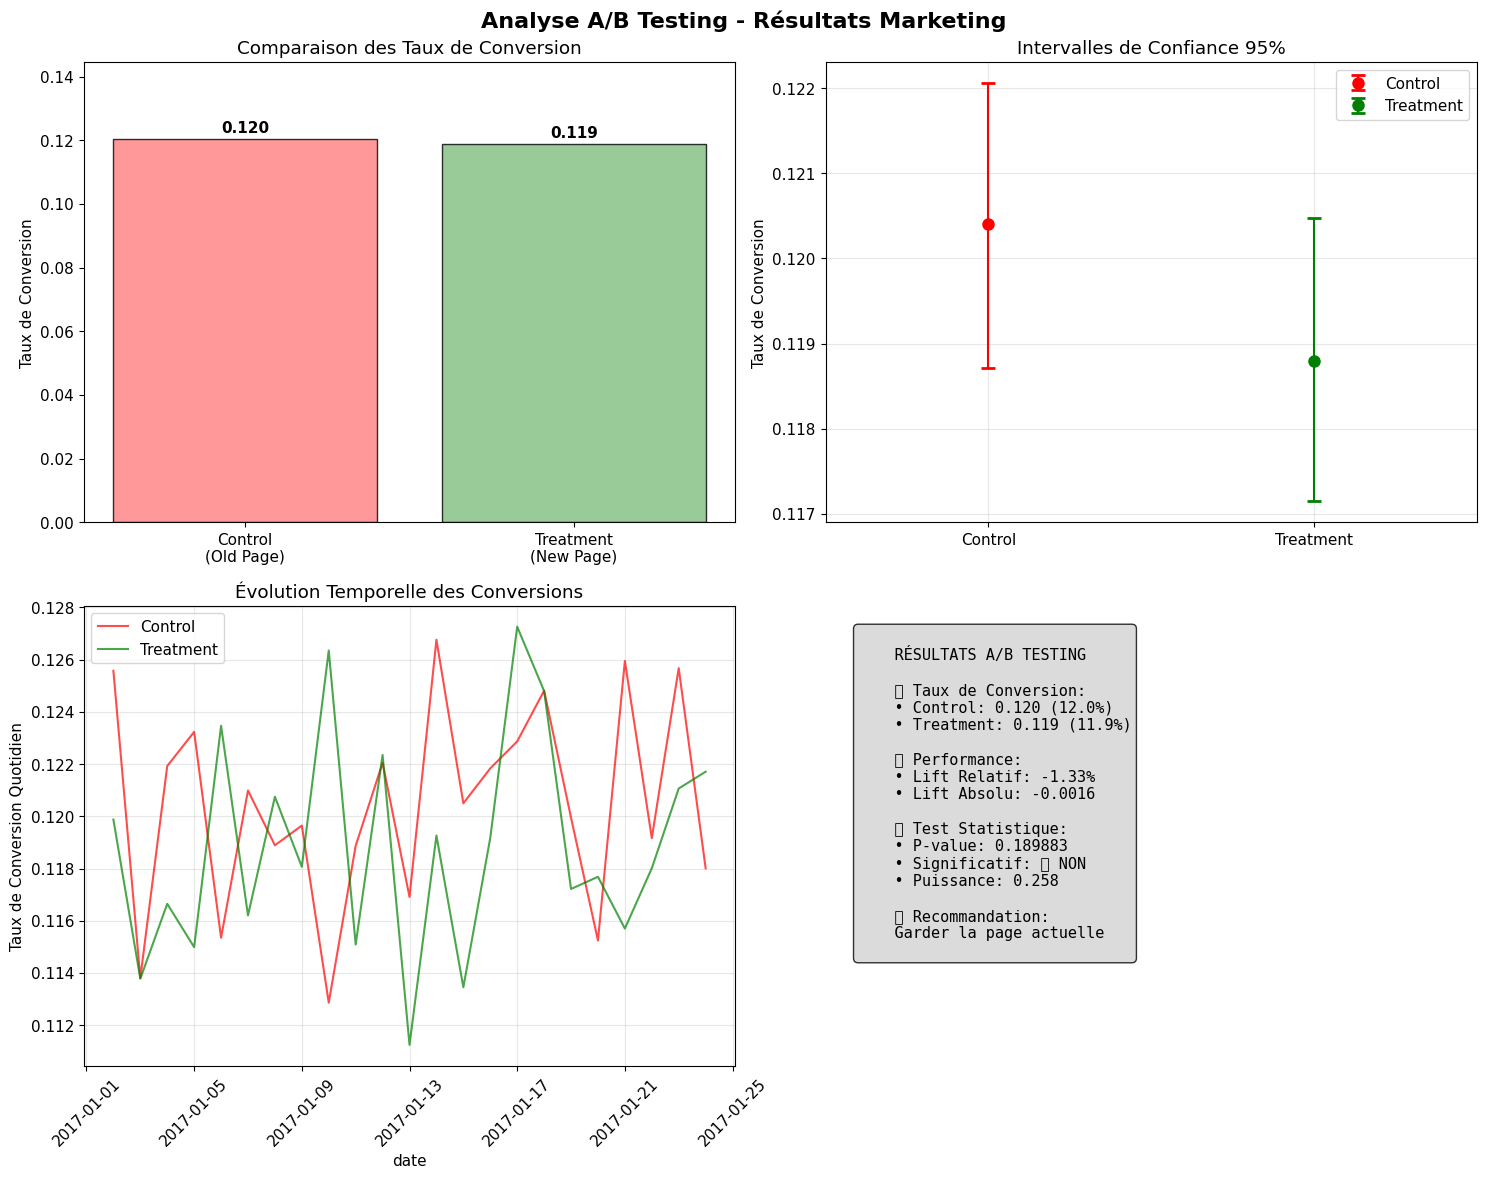

  ✅ Graphiques sauvegardés dans 'ab_testing_results.png'

🎯 Recommandation: RÉSULTAT NON CONCLUANT | Confiance: FAIBLE
   Significatif: ❌ | Impact: -1.33% de variation du taux de conversion


In [16]:
print("Génération des graphiques et des recommandations business...")

try:
    visualize_results(df_clean, conversion_metrics, statistical_results, save_plots=True)
    print("  ✅ Graphiques sauvegardés dans 'ab_testing_results.png'")
except Exception as e:
    print(f"  ⚠️ Impossible de générer les graphiques: {e}")

recommendations = generate_business_recommendations(
    conversion_metrics, statistical_results, confidence_level=0.95
)

exec_summary = recommendations['executive_summary']
print(f"\n🎯 Recommandation: {exec_summary['recommendation']} | Confiance: {exec_summary['confidence_level']}")
print(f"   Significatif: {'✅' if exec_summary['statistical_significance'] else '❌'} | Impact: {exec_summary['business_impact']}")


## 📋 PHASE 9 : RAPPORT DE SYNTHÈSE FINAL

In [18]:
# Génération du rapport complet
print("📋 Génération du rapport de synthèse...")
final_report = create_summary_report(
    df_clean, conversion_metrics, statistical_results, recommendations
)
print(final_report)

📋 Génération du rapport de synthèse...

    ╔══════════════════════════════════════════════════════════════════════════════════╗
    ║                           RAPPORT A/B TESTING MARKETING                          ║
    ╚══════════════════════════════════════════════════════════════════════════════════╝
    
    📅 Date d'analyse: 2025-08-11 21:54:25
    📊 Période des données: 2017-01-02 à 2017-01-24
    
    ┌─ RÉSUMÉ EXÉCUTIF ─────────────────────────────────────────────────────────────────┐
    │ Recommandation: RÉSULTAT NON CONCLUANT │
    │ Confiance: FAIBLE                         │
    │ Impact Business: -1.33% de variation du taux de conversion │
    └───────────────────────────────────────────────────────────────────────────────────┘
    
    ┌─ MÉTRIQUES CLÉS ──────────────────────────────────────────────────────────────────┐
    │ Groupe Contrôle (Ancienne Page):                                                 │
    │   • Utilisateurs: 145,274                               